<figure style="text-align: center;">
  <img src="_static/intro/title_page.png" style="display: block; margin: 0 auto; width: 100%;">
</figure>

### Attention

Michael J. Pyrcz, Professor, The University of Texas at Austin 

[Twitter](https://twitter.com/geostatsguy) | [GitHub](https://github.com/GeostatsGuy) | [Website](http://michaelpyrcz.com) | [GoogleScholar](https://scholar.google.com/citations?user=QVZ20eQAAAAJ&hl=en&oi=ao) | [Geostatistics Book](https://www.amazon.com/Geostatistical-Reservoir-Modeling-Michael-Pyrcz/dp/0199731446) | [YouTube](https://www.youtube.com/channel/UCLqEr-xV-ceHdXXXrTId5ig)  | [Applied Geostats in Python e-book](https://geostatsguy.github.io/GeostatsPyDemos_Book/intro.html) | [Applied Machine Learning in Python e-book](https://geostatsguy.github.io/MachineLearningDemos_Book/) | [LinkedIn](https://www.linkedin.com/in/michael-pyrcz-61a648a1)

Chapter of e-book "Applied Machine Learning in Python: a Hands-on Guide with Code". 

```{admonition} Cite this e-Book as:
:class: remove-from-content-only

Pyrcz, M.J., 2024, *Applied Machine Learning in Python: A Hands-on Guide with Code* [e-book]. Zenodo. doi:10.5281/zenodo.15169138 [![DOI](https://zenodo.org/badge/863274676.svg)](https://doi.org/10.5281/zenodo.15169138) 
```

The workflows in this book and more are available here:

```{admonition} Cite the MachineLearningDemos GitHub Repository as:
:class: remove-from-content-only

Pyrcz, M.J., 2024, *MachineLearningDemos: Python Machine Learning Demonstration Workflows Repository* (0.0.3) [Software]. Zenodo. DOI: 10.5281/zenodo.13835312. GitHub repository: https://github.com/GeostatsGuy/MachineLearningDemos [![DOI](https://zenodo.org/badge/862519860.svg)](https://zenodo.org/doi/10.5281/zenodo.13835312)
```

By Michael J. Pyrcz <br />
&copy; Copyright 2024.

This chapter is a tutorial for / demonstration of **Attention**. 

**YouTube Lecture**: check out my lectures on:

* TBD

These lectures are all part of my [Machine Learning Course](https://youtube.com/playlist?list=PLG19vXLQHvSC2ZKFIkgVpI9fCjkN38kwf&si=XonjO2wHdXffMpeI) on YouTube with linked well-documented Python workflows and interactive dashboards. My goal is to share accessible, actionable, and repeatable educational content. If you want to know about my motivation, check out [Michael's Story](https://michaelpyrcz.com/my-story). 

#### Motivation and Why Attention?

In machine learning models, we need to determine which parts of the input matter most for each prediction.

Traditional approaches often rely on fixed notions of importance or local relationships. This can become limiting when,

* dependencies are long-range

* relevance depends on context

* the system contains many interacting components

Before attention mechanisms, many machine learning workflows relied on fixed local neighborhoods or sequential processing to assign importance. For example,

* linear regression uses a fixed set of coefficients that do not change with prediction context

* k-nearest neighbours only use information from the k most similar training samples

* support vector machines only consider data in the margin

* convolutional neural networks focus on local patterns through finite receptive fields, requiring many layers to capture long-range relationships

* recurrent neural networks process information sequentially and may struggle to preserve information across long sequences

In many real-world problems, important relationships may occur between locations, observations, or events that are far apart in feature space, geographic position, or time sequence. To illustrate with a book analogy, the important information that we need now may have been presented many pages previously.

Attention addresses this limitation by allowing the model to dynamically determine:

* what information is relevant?

* where is the relevant information located?

* how strongly should each piece of information influence the prediction?

Attention mechanisms dynamically determine which parts of the input are most relevant for a specific prediction regardless of their position or distance from one another.

Instead of only using nearby information, attention allows each query to compare itself against many candidate observations, features, or patterns and retrieve information according to its weighted similarity.

This enables the model to capture long-range relationships and complex interactions without requiring information to be propagated through many intermediate processing steps.


#### Attention Concepts

Let's start describing the attention mechanism conceptually. The basic building blocks for attention include,

* **Query (Q)** — what information do I need right now?

* **Key (K)** — a descriptor used to determine whether stored analog information is relevant.

* **Value (V)** — the actual information associated with each key

Each key–value pair represents a reference (memory) piece of information, where the key describes the information and the value contains its content.

Now we put this together with this flow of information,

* similarity between the Query (Q) and Keys (K) $\rightarrow$ measures compatibility and produces relevance scores for all reference (memory) information

* scores $\rightarrow$ normalized (via softmax) into weights representing relative importance

* weighted sum of Values (V) $\rightarrow$ produces a context-aware output representation

```{admonition} We can describe attention qualitatively as,
:class: remove-from-content-only

a soft lookup mechanism over a set of stored analog information.
```

Now let's specify these concepts for the geoscience context to strengthen our connections to subsurface resource modeling,

* **Query (Q)** — current geological context

* **Key (K)** — descriptors of geological analogs stored in the reference (memory)

* **Value (V)** — associated reservoir properties (e.g., permeability) or subsurface responses (e.g., flow rates or recovery factors)

So, attention becomes a mechanism for identifying and combining information from relevant geological analogs. Now let's put these concepts together by walking through the attention workflow with words first, no math yet!


#### Attention Concepts with all Computer Science Concepts

For clarity, we have intentionally described attention using generic concepts such as stored analog information, descriptors, and context. In many computer science applications, especially natural language processing, these concepts are often expressed using more specialized terminology,

* **Token** — an individual unit of input information (e.g., a word, subword, character, image patch, or observation)

* **Embedding** — a numerical vector representation of a token or observation

* **Query (Q)** — a learned representation describing what information is needed from the current context

* **Key (K)** — a learned representation describing the characteristics of stored analog information

* **Value (V)** — a learned representation containing the information associated with each key

* **Attention Score** — a similarity measure between a query and a key

* **Attention Weight** — a normalized relevance score indicating the importance of each value

* **Context Vector** — the weighted combination of values produced by the attention mechanism

* **Transformer** — a neural network architecture built around attention mechanisms. Rather than relying primarily on sequential processing or fixed local neighborhoods, transformers use attention to determine which parts of the input should interact and exchange information.

In natural language models, tokens often correspond to words or word fragments. In subsurface resource modeling, tokens may instead represent locations, measurements, grid cells, wells, geological features, time steps, or other units of information. 

* The underlying attention mechanism remains the same.

Attention is the fundamental mechanism underlying transformer models. 

* While transformers were originally developed for natural language processing, the same attention concepts are now applied to images, time series, scientific data, and subsurface resource modeling.


#### Attention Workflow Conceptual Description

Let's walk through the fundamental attention-based information flow, first with a flow chart and then with words.

<figure style="text-align: center;">
  <img src="_static/attention/attention_workflow.png" style="display: block; margin: 0 auto; width: 40%;">
  <figcaption style="text-align: center;"> General attention workflow from keys, values and query to prediction.
</figcaption>
</figure>

Dot-product similarity measures the alignment between the Query (Q) and each Key (K) by multiplying corresponding components and summing the result. Larger dot products indicate stronger similarity and greater compatibility between patterns,

$$
\text{Query (Q)} \cdot \text{Key (K)} \rightarrow \text{Similarity} 
$$

The similarity calculation produces relevance scores that quantify how strongly each stored analog pattern matches the current query,

$$
\text{Similarity} \rightarrow \text{Scores} 
$$

Softmax normalization enforces closure by constraining the attention weights to sum to 1.0, producing a convex weighted combination of the values and Thus, the weights form a probability-like distribution that sums to one, producing a convex weighted combination of the values,

$$
\text{Softmax / Normalization(Scores)} \rightarrow \text{Weights}
$$

The attention weights are applied to the values to form a weighted combination that produces a context-aware output. Larger weights contribute more strongly to the prediction, allowing the model to dynamically retrieve and combine the most relevant stored analog information for the current query,

$$
\sum \text{Weights} \times \text{Values (V)} \rightarrow \text{Context Vector}
$$

This context vector can then be used directly or passed to subsequent layers to support the final prediction.


#### Vector and Matrix Math Reminder

Matrix notation is written as:

$$
\mathbf{A}_{r \times c}
$$

where:
- $r$ = number of rows  
- $c$ = number of columns  

So $\mathbf{A}_{r \times c}$ means a matrix with $r$ row elements and $c$ column elements.

We use the same general notation for vectors, the following is a row vector of with $c$ elements,

$$
\mathbf{v}_{1 \times c}
$$

and the following is a column vector with $r$ elements,

$$
\mathbf{v}_{r \times 1}
$$

For matrix multiplication,

$$
\mathbf{A}_{m \times n}
\mathbf{B}_{n \times p}
=
\mathbf{C}_{m \times p}
$$

The inner dimensions must match $(n = n)$ and the resulting matrix inherits the outer dimensions,

$$
(m \times p)
$$

For example,

$$
\mathbf{A}_{2 \times 3}
\mathbf{B}_{3 \times 4}
=
\mathbf{C}_{2 \times 4}
$$

Expanded,

$$
\begin{bmatrix}
a_{11} & a_{12} & a_{13} \\
a_{21} & a_{22} & a_{23}
\end{bmatrix}
\begin{bmatrix}
b_{11} & b_{12} & b_{13} & b_{14} \\
b_{21} & b_{22} & b_{23} & b_{24} \\
b_{31} & b_{32} & b_{33} & b_{34}
\end{bmatrix}
=
\begin{bmatrix}
c_{11} & c_{12} & c_{13} & c_{14} \\
c_{21} & c_{22} & c_{23} & c_{24}
\end{bmatrix}
$$

Each element of $\mathbf{C}$ is calculated as a dot product between a row of $\mathbf{A}$ and a column of $\mathbf{B}$,

$$
c_{ij}
=
\sum_{k=1}^{n} a_{ik} b_{kj}
$$

for example, 

$$
c_{11} = a_{11}b_{11} + a_{12}b_{21} + a_{13}b_{31}
$$

$$
c_{12} = a_{11}b_{12} + a_{12}b_{22} + a_{13}b_{32}
$$

Notice that matrix multiplication is fundamentally a collection of dot products. 

* this observation is important because attention relies heavily on dot-product similarity calculations between queries and keys,

With this vector and matrix notation, you will be able to follow the mathematical formulation of attention, where similarities between queries and keys are calculated through dot products and combined through matrix operations.

#### Attention Workflow Mathematical Formulation

Now let's revisit the same attention workflow, but this time with the full mathematical formulation and notation, including the dimensions of every vector and matrix so the structure is explicit and easy to follow.

Suppose we have,

* $N$ stored analog patterns or observations

* each pattern or observation is a feature vector of size $d$

* associated scalar or vector values to estimate or retrieve

##### Query Vector

The query vector represents the current pattern or context that we are trying to match against stored analog information.

$$
\mathbf{Q}_{1 \times d}
=
\begin{bmatrix}
q_1 & q_2 & \cdots & q_d
\end{bmatrix}
$$

where,

* $d$ = number of features in the query pattern

* $q_j$ = feature value $j$

In this formulation, the query represents the predictor location, while the key–value pairs represent information from previously observed locations used for inference, defined below.

##### Key Matrix

The key matrix contains all candidate stored analogs in the reference (memory), may be derived from data, physics-based models, analogs, etc.,

$$
\mathbf{K}_{N \times d}
=
\begin{bmatrix}
k_{11} & k_{12} & \cdots & k_{1d} \\
k_{21} & k_{22} & \cdots & k_{2d} \\
\vdots & \vdots & \ddots & \vdots \\
k_{N1} & k_{N2} & \cdots & k_{Nd}
\end{bmatrix}
$$

where, $N$ is the number of stored analogs, row $i$ represents stored analog $i$, and each row is paired with an associated value.

##### Value Vector

The value vector contains the information associated with each stored analog key. For simplicity, we begin with scalar values. Vector-valued outputs generalize this formulation directly.

$$
\mathbf{V}_{N \times 1}
=
\begin{bmatrix}
v_1 \\
v_2 \\
\vdots \\
v_N
\end{bmatrix}
$$

where $v_i$ is the value associated with key $i$. For simplicity, we begin with scalar values. The extension to vector-valued representations follows naturally.

##### Dot-Product Similarity

Attention begins by measuring similarity between the query and every key.

For a single key,

$$
s_i
=
\mathbf{Q}\mathbf{K}_i^T
=
\sum_{j=1}^{d} q_j k_{ij}
$$

where $s_i$ is the similarity score for stored analog $i$, and larger values indicate stronger alignment between the query and key.

Using all keys simultaneously we calculate the scores for every key,

$$
\mathbf{S}_{1 \times N}
=
\mathbf{Q}_{1 \times d}
\mathbf{K}_{N \times d}^T
$$

note, the transposed matrix $K^T$ has dimensions $d \times N$, i.e., $\{K^T\}_{d \times N}$; therefore, the inner dimensions match. In scaled dot-product attention,

$$
\mathbf{S}
=
\alpha\mathbf{Q}\mathbf{K}^T
$$

where $\alpha$ is a scaling factor or temparature parameter to stabilize the magnitude of the similarity scores, where a larger $\alpha$ sharpens attention sensitivity. In transformer architectures, $\alpha$ is commonly chosen as $\frac{1}{\sqrt{d}}$.

$$
\mathbf{S}
=
\frac{\mathbf{Q}\mathbf{K}^T}{\sqrt{d}}
$$

##### Similarity Scores

The similarity operation produces a score for every stored analog,

$$
\mathbf{S}_{1 \times N}
=
\begin{bmatrix}
s_1 & s_2 & \cdots & s_N
\end{bmatrix}
$$

These scores quantify the compatibility between the current query and each stored analog.


##### Softmax Normalization

The similarity scores are transformed into attention weights using softmax normalization. For each stored analog,

$$
w_i
=
\frac{\exp(s_i)}
{\sum_{k=1}^{N} \exp(s_k)}
$$

Collectively,

$$
\mathbf{W}_{1 \times N}
=
\text{softmax}(\mathbf{S})
$$

with properties,

$$
0 \leq w_i \leq 1
$$

and,

$$
\sum_{i=1}^{N} w_i = 1
$$

Thus, the weights form a probability-like distribution that sums to one, producing a convex weighted combination of the values.

Large similarity scores produce larger attention weights and greater influence on the output context vector.


##### Attention Prediction

The final output vector is obtained through a weighted combination of the stored analogs' associated values,

$$
\hat{y}
=
\sum_{i=1}^{N} w_i v_i
$$

or equivalently,

$$
\hat{y}
=
\mathbf{W}_{1 \times N}
\mathbf{V}_{N \times 1}
$$

where $\hat{y}$ is the predicted output or context-aware representation, and larger attention weights contribute more strongly to the prediction.

Again, because the weights sum to 1.0, the output context-aware representation is a convex weighted combination of the stored analogs' values.

* these normalized attention weights determine how strongly each stored analogs' values contribute to the final context-aware representation.


##### Interpretation

Attention dynamically retrieves and combines information based on similarity between the query and stored analag. Qualitatively, we can state this as,

* attention acts as a soft lookup mechanism over a set of stored analogs.

We demonstrate attention with two examples, 

* prediction given a set of analogs in a data table - using similarity of a single scalar feature

* prediction of a missing well log with an available common well log - using both magnitude and shape similarity across features


#### Import Required Packages

We will also need some standard packages. These should have been installed with Anaconda 3.

In [1]:
suppress_warnings = True                                      # toggle to supress warnings
import os                                                     # to set current working directory 
import math                                                   # square root operator
import numpy as np                                            # arrays and matrix math
import pandas as pd                                           # DataFrames
import matplotlib.pyplot as plt                               # for plotting
import matplotlib.patches as patches                          # draw neural network nodes
from matplotlib.ticker import (MultipleLocator, AutoMinorLocator, AutoLocator) # control of axes ticks
plt.rc('axes', axisbelow=True)                                # grid behind plotting elements
if suppress_warnings == True:  
    import warnings                                           # supress any warnings for this demonstration
    warnings.filterwarnings('ignore') 
seed = 13                                                     # random number seed for workflow repeatability

If you get a package import error, you may have to first install some of these packages. This can usually be accomplished by opening up a command window on Windows and then typing 'python -m pip install [package-name]'. More assistance is available with the respective package docs.  

#### Declare Functions

To support the two prediction demonstrations and their visualizations, we define a set of helper functions that implement the attention workflow in both distance-based and dot-product forms.

These functions operate on geoscience-style tabular data (e.g., well logs, spatial observations, or geological descriptors),

* **build_keys** — extract feature vectors representing geological descriptors from a DataFrame

* **build_values** — extract target property values associated with each key

* **build_query** — construct the query vector representing the target prediction location or interval

* **similarity_basic** — compute similarity using negative squared Euclidean distance (basic distance-based weighting)

* **similarity** — distance-based similarity with temperature control to adjust sensitivity

* **dot_similarity** — scaled dot-product similarity (attention-style) with temperature control

* **dot_similarity_norm** — scaled dot-product similarity with normalization to reduce magnitude bias

* **softmax** — convert similarity scores into normalized attention weights

* **attention** — full attention mechanism: compute weights and weighted output

* **dot_attention** — dot-product attention mechanism

* **dot_attention_norm** — normalized dot-product attention mechanism

* **attention_entropy** — compute entropy of the attention weight distribution for a given query

* **plot_well_log_data** — visualize training data and query location for well logs

* **plot_attention_prediction_log** — visualize training data, query, and predictions

* **plot_attention_provenance** — show query window, keys, and attention weights (interpretability view)

* **plot_entropy_log** — visualize keys and attention weight distribution

* **plot_full_attention_matrix** — display full attention matrix as a heatmap

In [2]:
def build_keys(df):                                           # keys represent geological descriptors, simple 1D feature (porosity)
    return df[["Porosity"]].values

def build_values(df):                                         # values represent target property, log-permeability 
    return df["Log_Permeability"].values

def build_query(porosity_value):                              # query is the target location descriptor
    return np.array([porosity_value])

def similarity_basic(Q, K):                                   # compute similarity (dot-product style) between query and each key, simple negative squared distance (geology-friendly)   Here: 
    return -np.sum((K - Q) ** 2, axis=1)

def similarity(Q, K, scale=50.0):
    return scale * (-np.sum((K - Q) ** 2, axis=1))            # similarity with temperature control for more sensitivity

def dot_similarity(Q, K, scale=10.0):                         # scaled dot-product similarity (attention-style) with temperature control
    scores = K @ Q
    return scale * scores

def dot_similarity_norm(Q, K, scale=10.0):                    # dot similarity normalized to reduce magnitude bias
    Qn = Q / (np.linalg.norm(Q) + 1e-12)
    Kn = K / (np.linalg.norm(K, axis=1, keepdims=True) + 1e-12)
    scores = Kn @ Qn
    return scale * scores

def softmax(x):                                               # softmax normalization
    x = x - np.max(x)                                         # numerical stability
    exp_x = np.exp(x)
    return exp_x / np.sum(exp_x)

def attention(Q, K, V,scale):                                 # attention mechanism, compute attention weights and weighted output.
    scores = similarity(Q, K,scale)
    weights = softmax(scores)
    output = np.sum(weights * V)
    return weights, scores, output

def dot_attention(Q, K, V, scale=10.0):                       # dot-product attention mechanism.
    scores = dot_similarity(Q, K, scale)
    weights = softmax(scores)
    output = np.sum(weights * V)
    return weights, scores, output

def dot_attention_norm(Q, K, V, scale=10.0):                  # dot-product attention mechanism normalized
    scores = dot_similarity_norm(Q, K, scale)
    weights = softmax(scores)
    output = np.sum(weights * V)
    return weights, scores, output

def attention_entropy(weights):                               # calculate entropy of all attention weights for a query
    eps = 1e-12
    w = np.array(weights)
    return -np.sum(w * np.log(w + eps))

def plot_well_log_data(well1,well2):                          # plot the well log data
    n = len(well1); depth = well1["depth_index"]
    fig, axes = plt.subplots(1, 2, figsize=(10, 6), sharey=True)
    ax1 = axes[0]
    
    ax1.plot(well1["phi"], depth, color="tab:blue",label='Porosity')
    ax1.scatter(well1["phi"], depth,color="tab:blue",edgecolor='black',s=20,zorder=10)
    ax1.set_xlabel("Porosity"); ax1.set_ylabel("Depth Index")
    ax1.set_title("Well 1 (Training)"); ax1.invert_yaxis(); plt.ylim([40,0])
    
    ax1.xaxis.set_minor_locator(AutoMinorLocator()); ax1.yaxis.set_minor_locator(AutoMinorLocator())
    ax1.grid(True, which="major", linestyle="-", linewidth=0.8, alpha=0.6)
    ax1.grid(True, which="minor", linestyle=":", linewidth=0.5, alpha=0.4)
    
    ax1b = ax1.twiny()
    ax1b.plot(well1["logk"], depth, color="tab:red",label='Log Permeability')
    ax1b.scatter(well1["logk"], depth,color="tab:red",edgecolor='black',s=20,zorder=10)
    ax1b.set_xlabel("Log-Permeability"); ax1.legend(loc='upper left')
    ax1b.xaxis.set_minor_locator(AutoMinorLocator()); ax1b.grid(False)
    
    ax2 = axes[1]
    ax2.plot(well2["phi"], depth,color="tab:blue",label='Porosity')
    ax2.scatter(well2["phi"], depth,color="tab:blue",edgecolor='black',s=20,zorder=10)
    ax2.set_xlabel("Porosity"); ax2.set_title("Well 2 (Target)")
    ax2.invert_yaxis(); plt.ylim([40,0]); ax2.legend(loc='upper left')
    ax2.xaxis.set_minor_locator(AutoMinorLocator())
    ax2.yaxis.set_minor_locator(AutoMinorLocator())
    ax2.grid(True, which="major", linestyle="-", linewidth=0.8, alpha=0.6)
    ax2.grid(True, which="minor", linestyle=":", linewidth=0.5, alpha=0.4)
    
    ax1.set_ylim([40,0]); plt.tight_layout()
    plt.subplots_adjust(left=0.0, bottom=0.0, right=1.0, top=1.5, wspace=0.2, hspace=0.6); plt.show()

def plot_attention_prediction_log(well1,well2):               # plot training, query and predictions 
    depth_full = np.arange(len(well2))  
    fig, axes = plt.subplots(1, 2, figsize=(10, 6), sharey=True)               
    ax1 = axes[0]                                             # plot training data 
    ax1.plot(well1["phi"], depth_full, color="tab:blue",label='Porosity')
    ax1.scatter(well1["phi"], depth_full,color="tab:blue",edgecolor='black',s=20,zorder=10)
    ax1.set_xlabel("Porosity"); ax1.set_ylabel("Depth Index")
    ax1.set_title("Well 1 (Training)"); ax1.invert_yaxis(); plt.ylim([40,0])
    
    ax1.xaxis.set_minor_locator(AutoMinorLocator()); ax1.yaxis.set_minor_locator(AutoMinorLocator())
    ax1.grid(True, which="major", linestyle="-", linewidth=0.8, alpha=0.6)
    ax1.grid(True, which="minor", linestyle=":", linewidth=0.5, alpha=0.4)
    
    ax1b = ax1.twiny()
    ax1b.plot(well1["logk"], depth_full, color="tab:red",label='Log Permeability')
    ax1b.scatter(well1["logk"], depth_full,color="tab:red",edgecolor='black',s=20,zorder=10)
    ax1b.set_xlabel("Log-Permeability")
    ax1b.xaxis.set_minor_locator(AutoMinorLocator()); ax1b.grid(False)
    
    handles1, labels1 = ax1.get_legend_handles_labels()
    handles2, labels2 = ax1b.get_legend_handles_labels()
    ax1.legend(handles1 + handles2,labels1 + labels2,loc="upper left")

    ax2 = axes[1]                                             # plot queries and predictions
    ax2.plot(well2["phi"], depth_full,color="tab:blue",label='Porosity')
    ax2.scatter(well2["phi"], depth_full,color="tab:blue",edgecolor='black',s=20,zorder=10)
    ax2.set_xlabel("Porosity"); ax2.set_title("Well 2 (Target)")
    ax2.invert_yaxis(); plt.ylim([40,0]); ax2.legend(loc='upper left')
    ax2.xaxis.set_minor_locator(AutoMinorLocator())
    ax2.yaxis.set_minor_locator(AutoMinorLocator())
    ax2.grid(True, which="major", linestyle="-", linewidth=0.8, alpha=0.6)
    ax2.grid(True, which="minor", linestyle=":", linewidth=0.5, alpha=0.4)
    ax2b = ax2.twiny()
    ax2b.plot(well2_attn["pred_logk"], well2_attn["depth_index"],alpha=0.2,color="tab:red",label='Predicted Log Permeability')
    ax2b.scatter(well2_attn["pred_logk"], well2_attn["depth_index"],color="tab:red",edgecolor='black',s=20,zorder=10)
    
    handles1, labels1 = ax2.get_legend_handles_labels(); handles2, labels2 = ax2b.get_legend_handles_labels()
    ax2.legend(handles1 + handles2,labels1 + labels2,loc="upper left")

    plt.tight_layout()
    plt.subplots_adjust(left=0.0, bottom=0.0, right=1.0, top=1.5, wspace=0.2, hspace=0.6); plt.show()

def plot_attention_provenance(well1,well2,all_weights,Q2,depth_index,window=3): # plot query window and reference (memory) well with attention weights
    half = window // 2
    q_idx = depth_index - half
    if q_idx < 0 or q_idx >= len(all_weights):
        raise ValueError("depth_index outside valid window range")
    weights = all_weights[q_idx];query = np.asarray(Q2[q_idx]).ravel()
    depth = np.arange(len(well1))

    fig, axes = plt.subplots(1, 2, figsize=(12, 6), sharey=False) 

    ax0 = axes[0]                                             # plot well 1 with query window
    ax0.plot(well2["phi"].values,depth,color="tab:blue",linewidth=2,label="Well 2 Porosity")
    ax0.plot(query,get_query_depth_window(depth_index, window),marker="o",color="black",
        linewidth=3,label="Query Window",zorder=10)
    ax0.set_title(f"Well 2 Query (Depth {depth_index})"); ax0.set_xlabel("Porosity"); ax0.set_ylabel("Depth")
    ax0.set_ylim(40, 0); ax0.grid(True, alpha=0.5); ax0.legend(loc="lower right")

    ax1 = axes[1]                                             # plot well 2 with attention weights
    ax1.plot(well1["phi"].values,depth,color="tab:blue",linewidth=2,label="Well 1 Porosity")
    ax1.set_title("Well 1 - Reference (Memory) Well"); ax1.set_xlabel("Porosity"); ax1.set_ylim(40, 0); ax1.grid(True, alpha=0.5)

    ax1b = ax1.twiny()
    ax1b.barh(np.arange(len(weights)) + window//2,weights,color="tab:red",alpha=0.35,height=0.8,label='attention weights')

    ax1b.set_xlabel("Attention Weight"); ax1b.set_xlim(0, np.max(weights) * 1.1); ax1b.set_ylim(40, 0)
    
    h1, l1 = ax1.get_legend_handles_labels(); h2, l2 = ax1b.get_legend_handles_labels()

    ax1.legend(h1 + h2, l1 + l2, loc="lower right")

    plt.tight_layout()
    plt.subplots_adjust(left=0.0, bottom=0.0, right=1.0, top=1.5, wspace=0.2, hspace=0.6); plt.show()

def plot_entropy_log(well2,all_weights):                      # plot well 2 query and attention entropy
    n = len(all_weights)
    entropy = np.array([                                      # calucalte entropy per depth (windowed attention)            
        attention_entropy(all_weights[i])
        for i in range(n)
    ])
    depth_attn = np.arange(n) + 1                             # calcualte window centers for plotting
    depth_full = np.arange(len(well2))  

    fig, axes = plt.subplots(1, 2, figsize=(12, 6), sharey=True)
    ax0 = axes[0]                                             # plot well 2 query
    ax0.plot(well2["phi"].values,depth_full,color="tab:blue",linewidth=2,label="Well 2 Porosity")
    ax0.set_title("Well 2 Porosity Log"); ax0.set_xlabel("Porosity"); ax0.set_ylabel("Depth Index")
    ax0.set_ylim(0, 40); ax0.grid(True, alpha=0.5); ax0.legend(loc="lower left")

    ax1 = axes[1]                                             # plot entropy log
    ax1.barh(depth_attn,entropy,color="red",alpha=0.4,height=0.8,label="Attention Entropy")
    ax1.set_title("Attention Entropy vs Depth"); ax1.set_xlabel("Entropy (Uncertainty)"); ax1.set_ylabel("Depth Index")
    ax1.set_ylim(0, 40); ax1.set_xlim(2.0,4.0); ax1.grid(True, alpha=0.5); ax1.legend(loc="lower right")

    plt.tight_layout()
    plt.subplots_adjust(left=0.0, bottom=0.0, right=1.0, top=1.5, wspace=0.2, hspace=0.6); plt.show()

def plot_full_attention_matrix(all_weights):                  # plot the entire attention matrix as a heat map
    attention_matrix = np.vstack(all_weights)
        
    fig, ax = plt.subplots(figsize=(8, 7))

    im = ax.imshow(attention_matrix,origin="upper",aspect="auto") # plot attention heat map
    ax.set_title("Attention Weight Matrix"); ax.set_xlabel("Well 1 Window Index (Keys)")
    ax.set_ylabel("Well 2 Window Index (Queries)")
    ax.set_xticks(np.arange(0, attention_matrix.shape[1], 5))
    ax.set_yticks(np.arange(0, attention_matrix.shape[0], 5))
    ax.set_xticks(np.arange(-0.5, attention_matrix.shape[1], 1), minor=True)
    ax.set_yticks(np.arange(-0.5, attention_matrix.shape[0], 1), minor=True)
    ax.grid(which="minor", color="white", linestyle="-", linewidth=0.2)
    ax.tick_params(which="minor", bottom=False, left=False)
    cbar = plt.colorbar(im, ax=ax)
    cbar.set_label("Attention Weight")
    
    plt.tight_layout()
    plt.subplots_adjust(left=0.0, bottom=0.0, right=1.0, top=0.8, wspace=0.2, hspace=0.6); plt.show()

def comma_format(x, pos):                                     # comma notation on axes
    return f'{int(x):,}'

def align_values(x, window=3):                                # align scalar values to window centers.
    half = window // 2
    return x[half:len(x) - half]

def center_crop(x, window):
    half = window // 2
    return x[half:len(x) - half]

def get_query_depth_window(depth_index, window):              # return the depth indices covered by the query window.
    half = window // 2
    return np.arange(depth_index - half, depth_index + half + 1)

def build_windows(x, window=3):                               # build sliding windows of a 1D log.
    n = len(x)
    half = window // 2
    X = []
    for i in range(half, n - half):
        X.append(x[i - half:i + half + 1])
    return np.array(X)

def add_grid():                                               # add grid lines to plot
    plt.gca().grid(True, which='major',linewidth = 1.0); plt.gca().grid(True, which='minor',linewidth = 0.2) # add y grids
    plt.gca().tick_params(which='major',length=7); plt.gca().tick_params(which='minor', length=4)
    plt.gca().xaxis.set_minor_locator(AutoMinorLocator()); plt.gca().yaxis.set_minor_locator(AutoMinorLocator()) # turn on minor ticks 

def add_grid2(sub_plot):
    sub_plot.grid(True, which='major',linewidth = 1.0); sub_plot.grid(True, which='minor',linewidth = 0.2) # add y grids
    sub_plot.tick_params(which='major',length=7); sub_plot.tick_params(which='minor', length=4)
    sub_plot.xaxis.set_minor_locator(AutoMinorLocator()); sub_plot.yaxis.set_minor_locator(AutoMinorLocator()) # turn on minor ticks

#### Analog Data Table Attention Demonstration

We now develop a simple, intuitive example of attention using a small analog reservoir dataset consisting of five samples. Each sample represents a geological analog with associated petrophysical properties.

For each sample, we include,

1. Sample index

2. Lithofacies

3. Depositional system

4. Porosity

5. Permeability

6. Natural log-transformed permeability

To keep the model as simple as possible, we assume that at a new location we only observe porosity, and we wish to estimate the corresponding permeability.

We define,

* **Query (Q)** — the porosity value at the location where we want to make a prediction
  
* **Keys (K)** — porosity as the feature used for similarity comparison with the analog dataset
  
* **Values (V)** — the corresponding permeability values associated with each analog sample

Attention then provides a way to determine which stored analogs are most relevant to the query by comparing similarity in feature space and using this to weight their contributions to the prediction.

In this context, attention answers the question,

* which past geological analogs are most informative for predicting permeability at this location?

##### Subsurface Analog Dataset (Attention Keys & Values)

The analog dataset is defined below as a small set of geological examples representing different depositional environments. Each sample provides a key (porosity used for similarity comparison) and an associated value (permeability used for prediction).

* **Keys (K)** define how similarity to the query is computed

* **Values (V)** define what information is retrieved and combined

| ID | Lithofacies | Depositional System | Porosity ($\phi$) | Permeability ($mD$) | Log-Permeability ($ln(mD)$) |
|----|------------------|-------------|--------------|--------------------|---------------------------|
| 1  | Channel sand     | High-energy fluvial channel | 0.26 | 800  | 6.68 |
| 2  | Levee sand       | Overbank levee deposit      | 0.20 | 200  | 5.30 |
| 3  | Shale            | Low-energy mudstone         | 0.08 | 5    | 1.61 |
| 4  | Fractured zone   | Structural damage zone      | 0.18 | 1200 | 7.09 |
| 5  | Mixed facies     | Transitional depositional mix | 0.16 | 300  | 5.70 |

In this formulation:

* each key corresponds to a porosity value (feature used for similarity comparison)

* each value corresponds to permeability (target property to be estimated)

* each row represents a stored geological analog in the attention reference (memory) data table

The dataset defines the reference (memory), i.e., retrieval space over which attention computes similarity between the query location and stored geological analogs.

In [3]:
data = {                                                      # build geological analog dictionary
    "ID": [1, 2, 3, 4, 5],
    "Geological_Analog": ["Channel sand","Levee sand","Shale","Fractured zone","Mixed facies"],
    "Facies_Type": ["High-energy fluvial channel","Overbank levee deposit","Low-energy mudstone",
        "Structural damage zone","Transitional depositional mix"],
    "Porosity": [0.26, 0.20, 0.08, 0.18, 0.16],
    "Permeability_mD": [800, 200, 5, 1200, 300]}
df = pd.DataFrame(data)                                       # convert dictionary into a DataFrame
df["Log_Permeability"] = np.log(df["Permeability_mD"])        # compute and add log-permeability (natural log)
df.head()                                                     # display the DataFrame

,ID,Geological_Analog,Facies_Type,Porosity,Permeability_mD,Log_Permeability
0,1,Channel sand,High-energy fluvial channel,0.26,800,6.684612
1,2,Levee sand,Overbank levee deposit,0.20,200,5.298317
2,3,Shale,Low-energy mudstone,0.08,5,1.609438
3,4,Fractured zone,Structural damage zone,0.18,1200,7.090077
4,5,Mixed facies,Transitional depositional mix,0.16,300,5.703782


##### Subsurface Analog Query (Target Location)

We define a target subsurface location where we want to estimate permeability,

| Query ID | Porosity (ϕ) | Geological Interpretation |
|----------|--------------|---------------------------|
| Q        | 0.19         | Ambiguous sand-rich interval with moderate reservoir quality |

##### Subsurface Analog Attention Interpretation

In the attention framework:

* **Keys (K)** - geological descriptors of each analog (represented here only by porosity for simplicity)

* **Values (V)** - permeability (or log-permeability)

* **Query (Q)** - target location to be estimated (represented here only by porosity for simplicity)

The goal is to determine,

* which geological analogs are most similar to the query and should therefore contribute most strongly to the permeability estimate

We compute this in three steps:

* Similarity between the query and each analog (Key–Query comparison)

* Attention weights via softmax normalization

* Weighted permeability estimate using the attention weights

This produces a data-driven geological averaging system, where,

* permeability is inferred as a weighted mixture of geologically similar analogs based on similarity in feature space

##### Subsurface Analog Attention-Based Permeability Prediction Workflow

The workflow below applies a very simple attention workflow to estimate permeability from geological analogs. The workflow steps are,

1. Build keys $K$ from geological descriptors
   
2. Build values $V$ from permeability responses  

3. Define a query $Q$ for the target location  

4. Compute similarity scores between $Q$ and $K$  

5. Normalize similarity scores into attention weights  

6. Predict permeability from the weighted combination of values  

Now more details on each step,

1. Build Keys (K) - keys represent the geological descriptor space used to compare analog similarity. In this simple demonstration, keys are constructed from porosity values,

$$
K_i = \phi_i
$$

$\quad$ where $K_i is the key for analog $i = 1,\ldots,5$, and $\phi_i$ is its porosity.

2. Build Values (V) - values represent the quantities combined by the attention mechanism to produce the final prediction. Here, values are log-permeability,

$$
V_i = \ln(k_i)
$$

$\quad$ where $k_i$ is permeability of analog $i$.

3. Build Query (Q) - the query represents the target location where permeability is to be estimated,

$$
Q = \phi_{\text{target}}
$$

4. Compute Similarity Scores - similarity scores measure geological affinity between the query and each analog. In general attention models, similarity is often computed using a dot product,

$$
s_i = Q \cdot K_i
$$

$\quad$ For this demonstration, we instead use a distance-based formulation,

$$
s_i = -\alpha (K_i - Q)^2
$$

$\quad$  where $\alpha$ is a scaling (inverse temperature) parameter.

$\quad$  This formulation directly measures mismatch in feature space,

* small distance $\rightarrow$ high similarity

* large distance $\rightarrow$ low similarity

$\quad$ The negative sign converts dissimilarity into similarity.

$\quad$ The scaling parameter $\alpha$ controls sensitivity:

* larger values produce sharper attention, while smaller values produce smoother averaging.

$\quad$ Let's compare dot product vs distance-based similarity for the scalar case). For scalar features,

$$
K_i = k_i, \quad Q = q
$$

$\quad$ dot-product similarity becomes,

$$
s_i = qk_i
$$

$\quad$ In this case, similarity is driven by both magnitude and sign agreement, rather than explicit distance between values.

* to obtain a more geometrically interpretable measure of geological similarity, we use,

$$
s_i = -\alpha (k_i - q)^2
$$

$\quad$ This formulation has a clear geometric meaning,

* small distance $\rightarrow$ high similarity

* large distance $\rightarrow$ low similarity


5. Compute Attention Weights - similarity scores are normalized using softmax,

$$
w_i = \frac{e^{s_i}}{\sum_{j=1}^{N} e^{s_j}}
$$

$\quad$ These weights form a probability-like distribution over geological analogs,

$$
\sum_{i=1}^{N} w_i = 1
$$

6. Predict Log-Permeability - the predicted log-permeability is computed as a weighted average,

$$
\hat{V} = \sum_{i=1}^{N} w_i V_i
$$

$\quad$ or equivalently,

$$
\widehat{\ln(k)} = \sum_{i=1}^{N} w_i \ln(k_i)
$$

$\quad$ Because we modeled permeability in log-space, the final estimate is obtained by exponentiation,

$$
\hat{k} = e^{\hat{V}}
$$

$\quad$ Now we implement this workflow in code to verify the numerical behavior of attention in this simple geological analog system.

Here is the code for our simple attention-based permeability prediction workflow.

* to check the numerical details, please review the functions declared above

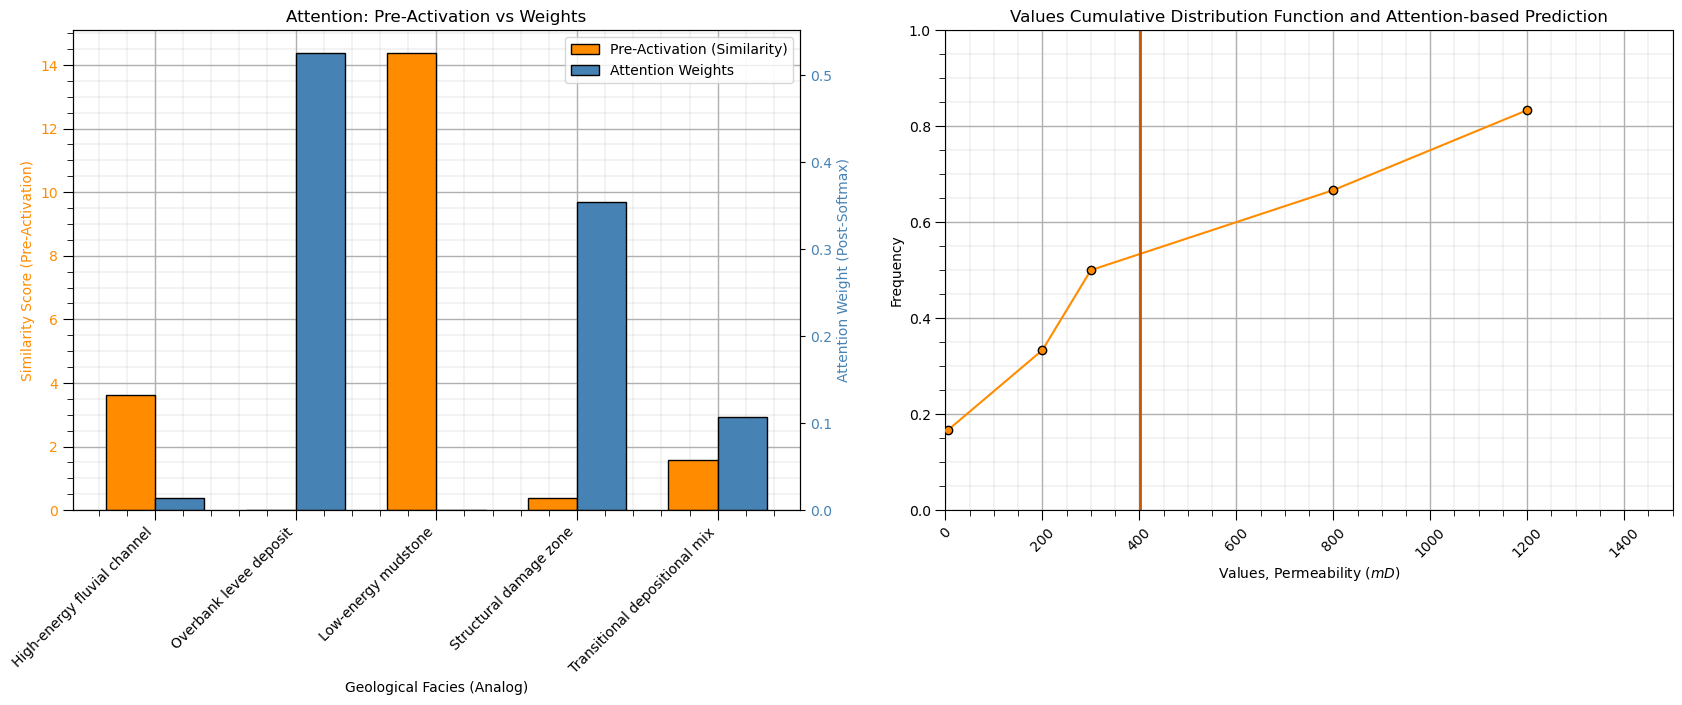

In [4]:
scale = 1000.0

K = build_keys(df)                                            # build Q, K, V
V = build_values(df)
Q = build_query(porosity_value=0.1999)                        # target location (query)

weights, pre_activation, pred_logK = attention(Q, K, V,scale) # run attention

pred_K = np.exp(pred_logK)                                    # convert back to permeability

labels = df["Facies_Type"].values                             # facies labels for interpretability
x = np.arange(len(labels))                                    # numeric positions
width = 0.35                                                  # bar width

labels = np.array(labels)
x = np.arange(len(labels))
width = 0.35

fig, axes = plt.subplots(1, 2, figsize=(10, 6))
ax1 = axes[0]

bars1 = ax1.bar(x - width/2,-1 * pre_activation,width=width,color="darkorange",edgecolor="black",  # plot pre-activation (similarity space)
    label="Pre-Activation (Similarity)") 

ax1.set_ylabel("Similarity Score (Pre-Activation)", color="darkorange")
ax1.tick_params(axis='y', labelcolor="darkorange")

ax1b = ax1.twinx()                                            # plot attention weights
bars2 = ax1b.bar(x + width/2,weights,width=width,color="steelblue",edgecolor="black",label="Attention Weights")

ax1b.set_ylabel("Attention Weight (Post-Softmax)", color="steelblue")
ax1b.tick_params(axis='y', labelcolor="steelblue")
ax1.set_xticks(x); add_grid2(ax1)
ax1.set_xticklabels(labels, rotation=45, ha="right")
ax1.set_xlabel("Geological Facies (Analog)")
ax1.set_title("Attention: Pre-Activation vs Weights")

handles1, labels1 = ax1.get_legend_handles_labels()           # combined legend
handles2, labels2 = ax1b.get_legend_handles_labels()

ax1.legend(handles1 + handles2, labels1 + labels2, loc="upper right")

ax2 = axes[1]                                                 # plot prediction on analog CDF
ax2.plot(np.sort(np.exp(V)),(np.arange(0, len(V))+1) / (len(V)+1),color='darkorange')
ax2.scatter (np.sort(np.exp(V)),(np.arange(0, len(V))+1) / (len(V)+1),color='darkorange',edgecolor='black',zorder=10)
ax2.set_xlabel(r"Values, Permeability ($mD$)")
ax2.set_ylabel("Frequency"); ax2.set_xlim([0.0,1500])
ax2.set_title("Values Cumulative Distribution Function and Attention-based Prediction")
ax2.tick_params(axis='x', rotation=45); add_grid2(ax2)
ax2.set_ylim([0,1]); ax2.axvline(x=np.exp(pred_logK),color='#CC5500',linewidth=2)

plt.tight_layout()
plt.subplots_adjust(left=0.0, bottom=0.0, right=1.6, top=0.8, wspace=0.2, hspace=0.6); plt.show()

##### Subsurface Analog Attention-Based Permeability Prediction Interpretation

This simple attention model performs a data-driven geological averaging process:

* geological similarity determines attention weights
  
* more similar analogs receive higher weights

* permeability is estimated as a weighted combination of analog responses

The scaling parameter $\alpha$ (or temperature) controls the selectivity of the attention mechanism,

* low $\alpha \rightarrow$ diffuse averaging across many analogs

* high $\alpha \rightarrow$ sharper selection of the most similar analogs

In this sense, the temperature parameter controls the transition from smooth probabilistic blending to near-deterministic analog selection.

For very large values of $\alpha$, the softmax can exhibit,

* saturation effects in the weight distribution

* convergence toward one-hot (or near one-hot) weights

* reduced representation of uncertainty across multiple analogs

Thus:

* high $\alpha \rightarrow$ nearest-analog behavior (hard selection limit)

* low $\alpha \rightarrow$ probabilistic blending across multiple geological analogs


#### Well Log Attention-Based Permeability Prediction

As a first step, we introduced a simple attention model in which:

* the query and key were scalars (single values)
  
* similarity was defined using negative squared difference

We now extend this formulation to a more realistic setting by introducing:

* vector-valued queries and keys (local windows of the well log)
  
* dot-product similarity between feature vectors

This extension allows the model to capture local spatial structure in addition to pointwise similarity.

We consider a well log prediction problem involving two wells:

* **Well 1 reference (memory) well** — contains both porosity and permeability measurements along the full interval (41 regularly spaced samples). This serves as the source of known geological patterns and responses.

* **Well 2 target well** — contains porosity only, and the goal is to estimate the missing permeability along the same interval.

Within the attention framework,

* **Keys (K)** — local porosity window vectors extracted from Well 1, centered at each depth location (i)

* **Values (V)** — permeability (or log-permeability) values from Well 1, aligned at the same depth locations as the keys

* **Queries (Q)** — local porosity window vectors extracted from Well 2, centered at each prediction location (j)

In this formulation, attention compares local porosity patterns between wells and uses similarity to transfer permeability information from the reference well to the target well in a data-driven manner.

##### Synthetic Well Log Generation Workflow

We construct a simple but geologically meaningful synthetic dataset consisting of two wells with different levels of available information.

1. Depth coordinate and workflow setup - we begin by defining a normalized depth coordinate to ensure reproducibility,

```python
n = 41
```

$$
z \in [0,n], \quad z = \text{linspace}(0,1,n)
$$

2. Well 1 porosity (composite geological signal) - porosity is generated as a superposition of geological processes including large-scale trends, cyclic bedding, fine-scale layering, and noise.

$\quad$ Physical bounds are enforced:

$$
\phi \in [0.02, 0.32]
$$

3. Implicit facies structure (rule-based classification) - we define depositional behavior using porosity thresholds:

* **Massive sand:** (\phi > 0.22)
  
* **Thin bed / shale-like:** (\phi < 0.10)
  
* **Transitional facies:** otherwise

4. Well 1 permeability model - permeability is assigned conditionally based on facies:

* Massive sand,
  $$
  k \sim \mathcal{N}(800, \sigma^2)
  $$

* Thin beds,
  $$
  k \sim \mathcal{N}(5, \sigma^2)
  $$

* Transitional facies,
  $$
  k = 50 + 3000(\phi - 0.10)^2 + \epsilon
  $$

$\quad$ where $\epsilon$ is Gaussian noise.

$\quad$ Physical constraints are enforced,

$$
k \ge 0
$$

$\quad$ We then compute:

$$
\log k
$$

5. Well 1 dataset assembly - we store all variables in a structured dataset,

$$
\text{Well 1} = {\text{depth}, \phi, k, \log k}
$$

6. Well 2 porosity (prediction-only well) - we construct a second porosity log with similar large-scale structure but different fine-scale variability,

$$
\phi_2(z) = 0.18 +  0.06 \sin(2\pi \cdot 2z) + 0.03 \sin(2\pi \cdot 6z + 4.0) + \epsilon
$$

$\quad$ The phase shift in fine-scale layering introduces realistic geological mismatch between wells.

$\quad$ Physical bounds are enforced,

$$
\phi_2 \in [0.02, 0.32]
$$

7. Well 2 dataset assembly - Well 2 contains only porosity,

$$
\text{Well 2} = {\text{depth}, \phi_2}
$$

8. Final dataset structure - the final workflow produces,

* a fully observed reference well (Well 1)
  
* a partially observed target well (Well 2)

This setup forms a controlled analog-to-target prediction problem suitable for testing attention-based permeability estimation.

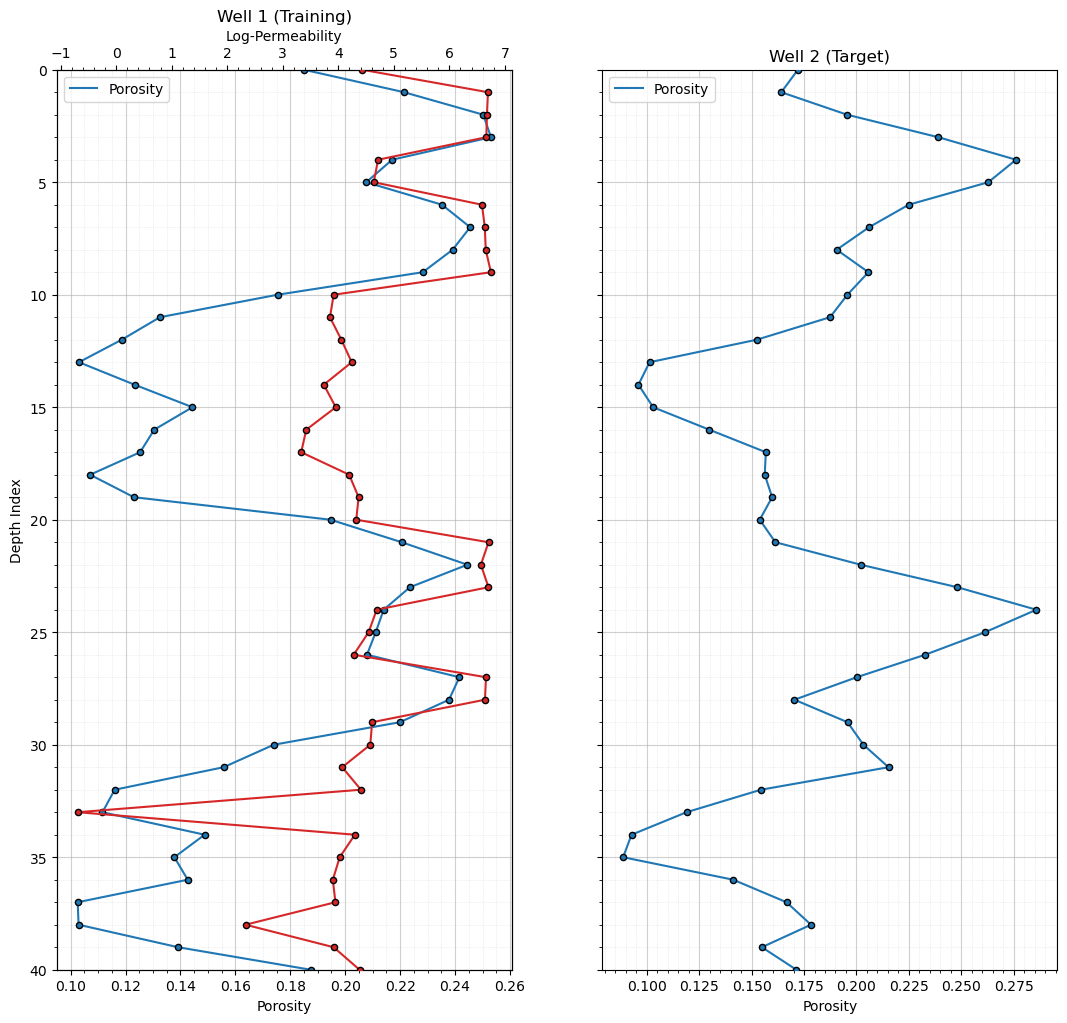

In [5]:
suppress_warnings = True                                      # toggle to supress warnings
np.random.seed(42)                                            # for workflow repeatability set the random number seed

n = 41                                                        # set the well log length
z = np.linspace(0, 1, n)                                      # pseudo-depth coordinate for synthetic data models

phi = (                                                       # Well 1: make porosity as a simple composite model with cycles, fine bedding and noise
    0.18
    + 0.06 * np.sin(2 * np.pi * z * 2)                        # cyclic bedding
    + 0.03 * np.sin(2 * np.pi * z * 6)                        # finer layering
    + 0.01 * np.random.randn(n)                               # small noise
)
phi = np.clip(phi, 0.02, 0.32)                                # clip to physical bounds

massive_sand = phi > 0.22                                     # define facies logic (implicit, not explicit labels)
thin_bed = phi < 0.10
transitional = ~(massive_sand | thin_bed)

k = np.zeros(n)                                               # calculate permeability model (Well 1 only) from porosity
k[massive_sand] = (800 + 50 * np.random.randn(np.sum(massive_sand))) # massive sand, high perm, low variance
k[thin_bed] = (5 + 2 * np.random.randn(np.sum(thin_bed)))     # thin beds, very low perm even if phi varies
k[transitional] = (50 + 300 * (phi[transitional] - 0.10) ** 2 * 10 + 20 * np.random.randn(np.sum(transitional))) # mixed, mod. nonlinear relations
k = np.clip(k, 0.5, None)                                     # enforce physical bounds
logk = np.log(k)                                              # log-permeability (for later attention model)
well1 = pd.DataFrame({"depth_index": np.arange(n),"phi": phi,"k_mD": k,"logk": logk}) # make well DataFrame

phi2 = (                                                      # Well 2: make porosity as a simple composite model with cycles, fine bedding and noise
    0.18
    + 0.06 * np.sin(2 * np.pi * z * 2)                        # cyclic bedding
    + 0.03 * np.sin(2 * np.pi * z * 6 + 4.0)                  # finer layering
    + 0.01 * np.random.randn(n)                               # small noise
)
phi2 = np.clip(phi2, 0.02, 0.32)                              # clip to physical bounds
well2 = pd.DataFrame({"depth_index": np.arange(n),"phi": phi2}) # make well DataFrame

n = len(well1); depth = well1["depth_index"]

plot_well_log_data(well1,well2)                               # plot the well log data

##### Mathematical Formulation

Now that we have introduced the general attention framework, we can summarize the specific workflow used for our well log permeability prediction problem. 

* yes this is quite verbose with the intention to describe a repeatable workflow, with every possible detail included.

The well log attention demonstration workflow steps are,

1. Extract local porosity windows from Well 1 to form the **keys (K)**

For a moving window of size $d$, centered at location $i$ in Well 1, each key vector is:

$$
\mathbf{K}_i
=
\begin{bmatrix}
\phi_{i-\frac{d-1}{2}} &
\phi_{i-\frac{d-3}{2}} &
\cdots &
\phi_i &
\cdots &
\phi_{i+\frac{d-3}{2}} &
\phi_{i+\frac{d-1}{2}}
\end{bmatrix}
$$

where $\phi_i$ is the porosity at depth/location $i$, $d$ is the moving window size, and $\mathbf{K}_i$ = local porosity pattern centered at location $i$

Collecting all valid windows produces the key matrix,

$$
\mathbf{K}_{N \times d}
=
\begin{bmatrix}
\mathbf{K}_1 \\
\mathbf{K}_2 \\
\vdots \\
\mathbf{K}_N
\end{bmatrix}
$$

where $N$ is the number of valid moving-window samples extracted from Well 1, and each $\mathbf{K}_k$ is a row vector that represents a stored local geological analog in the reference (memory) well. For example, a single key vector centered at location $i$ with a window size of $d=3$ is:

$$
\mathbf{K}_i
=
\begin{bmatrix}
\phi_{i-1} &
\phi_i &
\phi_{i+1}
\end{bmatrix}
$$

where $\phi_i$ is the porosity at location/depth index $i$, $\phi_{i-1}$ and $\phi_{i+1}$ provide the local geological context surrounding the center location, and $\mathbf{K}_i$ represents a local geological pattern extracted from the well log.

$$
\mathbf{K}_{N \times d}
=
\begin{bmatrix}
\phi_{1-1} & \phi_{1} & \phi_{1+1} \\
\phi_{2-1} & \phi_{2} & \phi_{2+1} \\
\phi_{3-1} & \phi_{3} & \phi_{3+1} \\
\vdots & \vdots & \vdots \\
\phi_{N-1} & \phi_{N} & \phi_{N+1}
\end{bmatrix}
$$

where each row represents a local porosity window (local geological pattern) extracted from Well 1 and centered at location $i$ and the full key matrix stacks all local geological patterns into the attention reference (memory) analog.

2. Pair each key window with the collocated permeability value from Well 1 to form the **values (V)**

For each key window centered at location $i$, we associate the collocated permeability value from Well 1,

$$
v_i = \ln(k_i)
$$

where $k_i$ is the permeability at location $i$, and $v_i$ = log-permeability value associated with key $\mathbf{K}_i$

Collecting all values forms the value vector:

$$
\mathbf{V}_{N \times 1}
=
\begin{bmatrix}
v_1 \\
v_2 \\
v_3 \\
\vdots \\
v_N
\end{bmatrix}
=
\begin{bmatrix}
\ln(k_1) \\
\ln(k_2) \\
\ln(k_3) \\
\vdots \\
\ln(k_N)
\end{bmatrix}
$$

Each value represents the target reservoir property retrieved from the reference (memory) well during attention-based prediction.

3. Extract local porosity windows from Well 2 to form the **queries (Q)**

For a moving window of size $d=3$, each query vector centered at location $j$ in Well 2 is,

$$
\mathbf{Q}_j
=
\begin{bmatrix}
\phi_{j-1} &
\phi_j &
\phi_{j+1}
\end{bmatrix}
$$

where $\phi_j$ is the porosity at location $j$ in Well 2, and $\mathbf{Q}_j$ = local porosity pattern at the prediction location

Collecting all valid query windows forms the query matrix,

$$
\mathbf{Q}_{M \times d}
=
\begin{bmatrix}
\phi_{1-1} & \phi_1 & \phi_{1+1} \\
\phi_{2-1} & \phi_2 & \phi_{2+1} \\
\phi_{3-1} & \phi_3 & \phi_{3+1} \\
\vdots & \vdots & \vdots \\
\phi_{M-1} & \phi_M & \phi_{M+1}
\end{bmatrix}
$$

where $M$ is the number of valid moving-window samples extracted from Well 2, and each row represents a local geological pattern where permeability is unknown and must be predicted

4. For each query window in Well 2, compute similarity against all key windows from Well 1 using scaled dot-product similarity

Let,

* $\mathbf{Q}_j \in \mathbb{R}^{1 \times d}$ be the query window at location $j$
* $\mathbf{K}_i \in \mathbb{R}^{1 \times d}$ be the key window at location $i$
* $d$ = window size
* $N$ = number of key windows in Well 1

The similarity between query $j$ and key $i$ is,

$$
s_{j,i} = \alpha \, \mathbf{Q}_j \cdot \mathbf{K}_i^{T}
$$

where $s_{j,i} \in \mathbb{R}$ is a scalar similarity score, $\mathbf{Q}_j \in \mathbb{R}^{1 \times d}$, $\mathbf{K}_i^{T} \in \mathbb{R}^{d \times 1}$, and $\alpha$ is a scaling (inverse temperature) parameter

Now let's look at this in matrix form with all keys at once. For a fixed query $\mathbf{Q}_j$, we compute similarity against all keys,

$$
\mathbf{s}_j = \alpha \mathbf{Q}_j \mathbf{K}^T
$$

where this is equivalent to computing dot products between $Q_j$ and each row of $K$.

Now let's work with the full attention score matrix with all queries vs all keys. If we compute similarities for all queries in Well 2,

$$
\mathbf{S}
=
\alpha \, \mathbf{Q} \mathbf{K}^{T}
$$

where $\mathbf{Q} \in \mathbb{R}^{M \times d}$ (Well 2 query windows), $\mathbf{K} \in \mathbb{R}^{N \times d}$ (Well 1 key windows), and $\mathbf{S} \in \mathbb{R}^{M \times N}$

Each entry,

$$
S_{j,i} = \alpha \sum_{m=1}^{d} Q_{j,m} K_{i,m}
$$

represents the similarity between query location $j$ and location $i$ in the reference (memory) well

5. Convert similarity scores into normalized attention weights using softmax

For a fixed query window $\mathbf{Q}_j$, we first compute a vector of similarity scores against all keys,

$$
\mathbf{s}_j =
\begin{bmatrix}
s_{j,1} \\
s_{j,2} \\
\vdots \\
s_{j,N}
\end{bmatrix}
\in \mathbb{R}^{N \times 1}
$$

where $s_{j,i} = \alpha \, \mathbf{Q}_j \cdot \mathbf{K}_i^T$

The attention weights are obtained from the similarity scores, $s_{j,k}$, by applying the softmax operator across all $N$ candidate analogs,

$$
w_{j,i}
=
\frac{\exp(s_{j,i})}
{\sum_{k=1}^{N} \exp(s_{j,k})} \quad i = 1, \dots, N
$$

This can be written compactly as,

$$
\mathbf{w}_j = \text{softmax}(\mathbf{s}_j)
$$

where $\mathbf{w}_j \in \mathbb{R}^{N \times 1}$, $\sum_{i=1}^{N} w_{j,i} = 1$, and $w_{j,i} \ge 0 \;\; \forall i$


6. Compute the permeability prediction as the weighted combination of permeability values retrieved from the most similar porosity patterns

For a fixed query location $j$, the predicted permeability is obtained by combining all stored analogs' values using the attention weights,

$$
\hat{y}_j
=
\sum_{i=1}^{N} w_{j,i} \, v_i
$$

where $w_{j,i}$ is the attention weight between query $j$ and key $i$, $v_i$ is the permeability (or log-permeability) associated with key $i$, and $N$ is the number of stored analog samples

This can be written compactly as,

$$
\hat{y}_j = \mathbf{w}_j^{T} \mathbf{v}
$$

where $\mathbf{w}_j \in \mathbb{R}^{N \times 1}$ is the attention weight vector, $\mathbf{v} \in \mathbb{R}^{N \times 1}$ is the value vector, and $\hat{y}_j \in \mathbb{R}$ is the predicted permeability at location $j$.

The full matrix form (all prediction locations), for all query locations in Well 2 is,

$$
\hat{\mathbf{y}} =
\mathbf{W} \mathbf{v}
$$

where $\mathbf{W} \in \mathbb{R}^{M \times N}$ is the attention weight matrix, $\mathbf{v} \in \mathbb{R}^{N \times 1}$ is the value vector from Well 1, and $\hat{\mathbf{y}} \in \mathbb{R}^{M \times 1}$ are the predicted permeability values for Well 2.

In this formulation, the model performs similarity-based retrieval of geological analog patterns from the reference well and transfers associated permeability information to the target well.


##### Results

Now here's the code for our attention-based permeability prediction from well log patterns workflow.

* to check the numerical details, please review the functions declared above

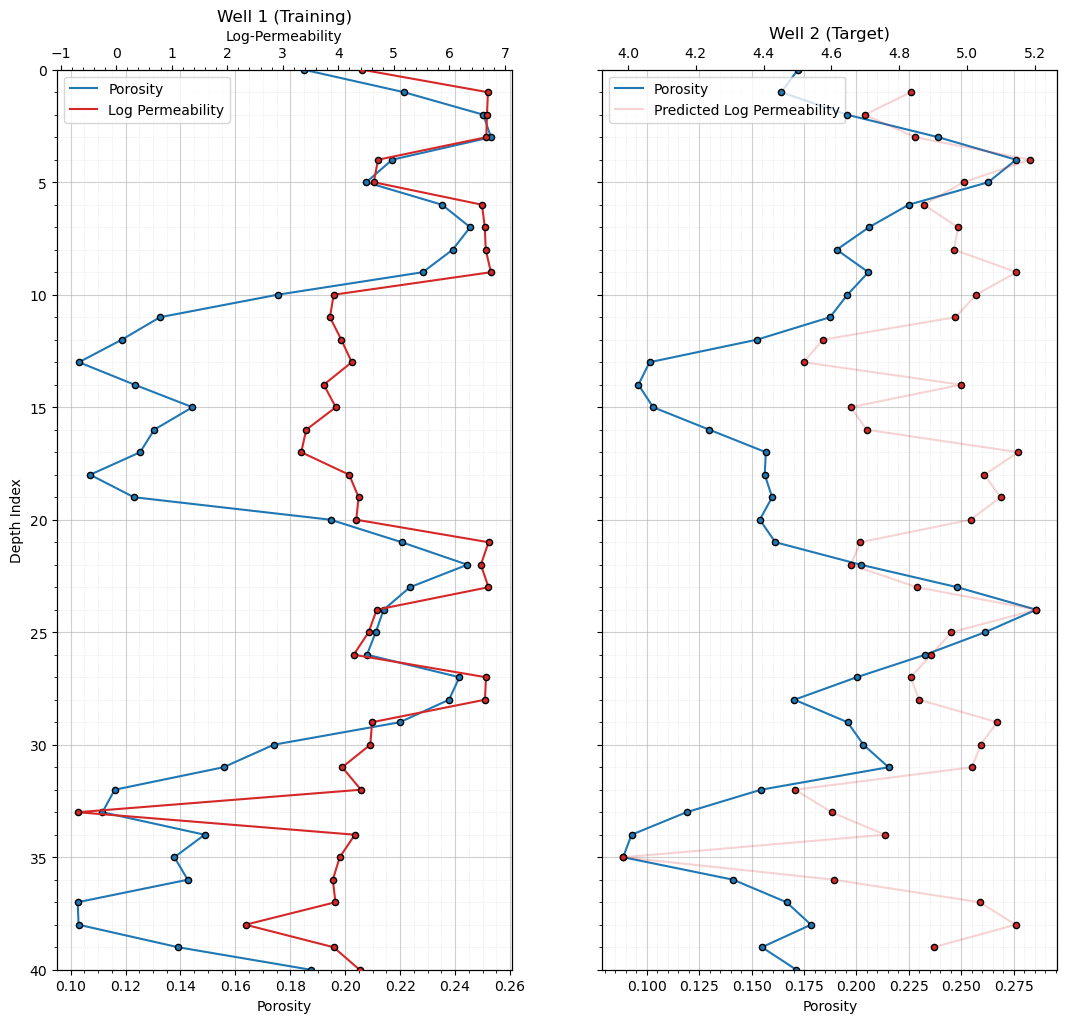

In [10]:
window = 3                                                    # model parameters 
scale = 100.0

phi1 = well1["phi"].values                                    # extract well logs
logk1 = well1["logk"].values

phi2 = well2["phi"].values

K1 = build_windows(phi1, window)                              # build Well 1 (keys + values)
V1 = center_crop(logk1, window)

Q2 = build_windows(phi2, window)                              # build Well 2 (queries)

pred_logk = []                                                # run attention over Well 2
all_weights = []
all_scores = []

for i in range(len(Q2)):
    #w, s, out = dot_attention(Q2[i], K1, V1, scale=scale)    # attention without normalization
    w, s, out = dot_attention_norm(Q2[i], K1, V1, scale=scale) # attention with normalization
    pred_logk.append(out)
    all_weights.append(w)
    all_scores.append(s)

pred_logk = np.array(pred_logk)

well2_attn = well2.iloc[window//2 : len(well2) - window//2].copy() # attach predictions
well2_attn["pred_logk"] = pred_logk
well2_attn["pred_k_mD"] = np.exp(pred_logk)

plot_attention_prediction_log(well1,well2)

To understand these results, let's talk about attention regimes and dot-product similarity interpretation.

##### Attention Regimes in Geological Sequence Modeling

To interpret how the scaling parameter $\alpha$ shapes model behavior, we examine different attention regimes and how they influence similarity-based retrieval in geological sequence modeling.

| Scale (α) | Attention Behavior | Weight Distribution | Geological Interpretation | ln(k) Output Behavior |
|-----------|--------------------|---------------------|---------------------------|------------------------|
| Low (≈ 1–10) | Diffuse attention | Nearly uniform weights | Global averaging of all analogs (weak discrimination) | Collapsed range, smooth mean-field (~global mean) |
| Medium (≈ 10–50) | Structured attention | Moderate peaks, partial selectivity | Local geological patterns influence prediction | Moderate variability, realistic smoothing |
| High (≈ 50–150) | Selective attention | Few dominant analogs per query | Analog-based geological transfer (pattern matching) | Wider range, facies-controlled structure emerges |
| Very high (≈ 150+) | Near-hard attention | Almost one-hot weights | Nearest-neighbor / MPS-like retrieval behavior | Highly variable, piecewise analog reconstruction |

Overall, increasing $\alpha$ transitions the system from smooth global averaging toward highly selective analog retrieval, where predictions shift from mean-field behavior to facies-controlled, pattern-driven reconstruction of permeability.

* the numerical ranges above are illustrative for this synthetic well-log example and depend on the scale and normalization of the query and key vectors.

In geological terms, increasing $\alpha$ shifts the model from broad averaging across many depositional analogs toward retrieval of a small number of highly similar local geological patterns.

##### Dot-Product Similarity Interpretation

In this formulation, similarity is defined as:

$$
s_i = \alpha \, (\mathbf{Q} \cdot \mathbf{K}_i)
$$

where $\mathbf{Q} \in \mathbb{R}^{1 \times d}$ is the query window, $\mathbf{K}_i \in \mathbb{R}^{1 \times d}$ is the $i$-th key window, $\mathbf{Q} \cdot \mathbf{K}_i = \sum_{m=1}^{d} Q_m K_{i,m}$ measures alignment between local geological patterns, and $\alpha$ is a scaling (inverse temperature) parameter  

Larger dot products indicate stronger alignment between porosity patterns, while smaller dot products indicate weaker similarity, leading to lower attention weights after softmax normalization.

This formulation contrasts with Euclidean distance-based similarity, which measures geometric separation rather than directional agreement in feature space,

* Before (Euclidean similarity), Which patterns are close in feature space?

* Now (dot-product similarity), Which patterns behave similarly in structure and trend?

This represents a subtle but important shift in interpretation:

* Euclidean distance $\rightarrow$ similarity through proximity in feature space
  
* Dot product $\rightarrow$ similarity through directional alignment and magnitude

Because the dot product is **scale-sensitive**, the magnitude of $\alpha$ strongly controls model behavior,

* small $\alpha$ $\rightarrow$ diffuse, nearly uniform attention
  
* moderate $\alpha$ $\rightarrow$ balanced analog selection
  
* large $\alpha$ $\rightarrow$ highly selective, near-nearest-neighbor retrieval  

In practice, stability is often improved by:

* normalizing query and key windows (cosine-like behavior), or
   
* keeping $\alpha$ in a moderate range (typically $\sim 5$–$50$ for well-log style signals)

This ensures attention reflects meaningful geological similarity rather than being dominated by magnitude effects.


##### Visualize the Attention Weights for a Single Prediction

To make the attention mechanism tangible, we now visualize a specific prediction location in Well 2 and trace how its local porosity pattern is matched against the reference (memory) well, recall Well 1. 

* well 2 porosity log with the query window highlighted at the chosen depth index (left)

* well 1 reference log alongside the corresponding attention weights computed at every candidate location (right)

Together, these plots illustrate how a single query activates a distributed set of geological analogs, and how the attention mechanism concentrates or disperses retrieval depending on pattern similarity across the reference (memory) well.

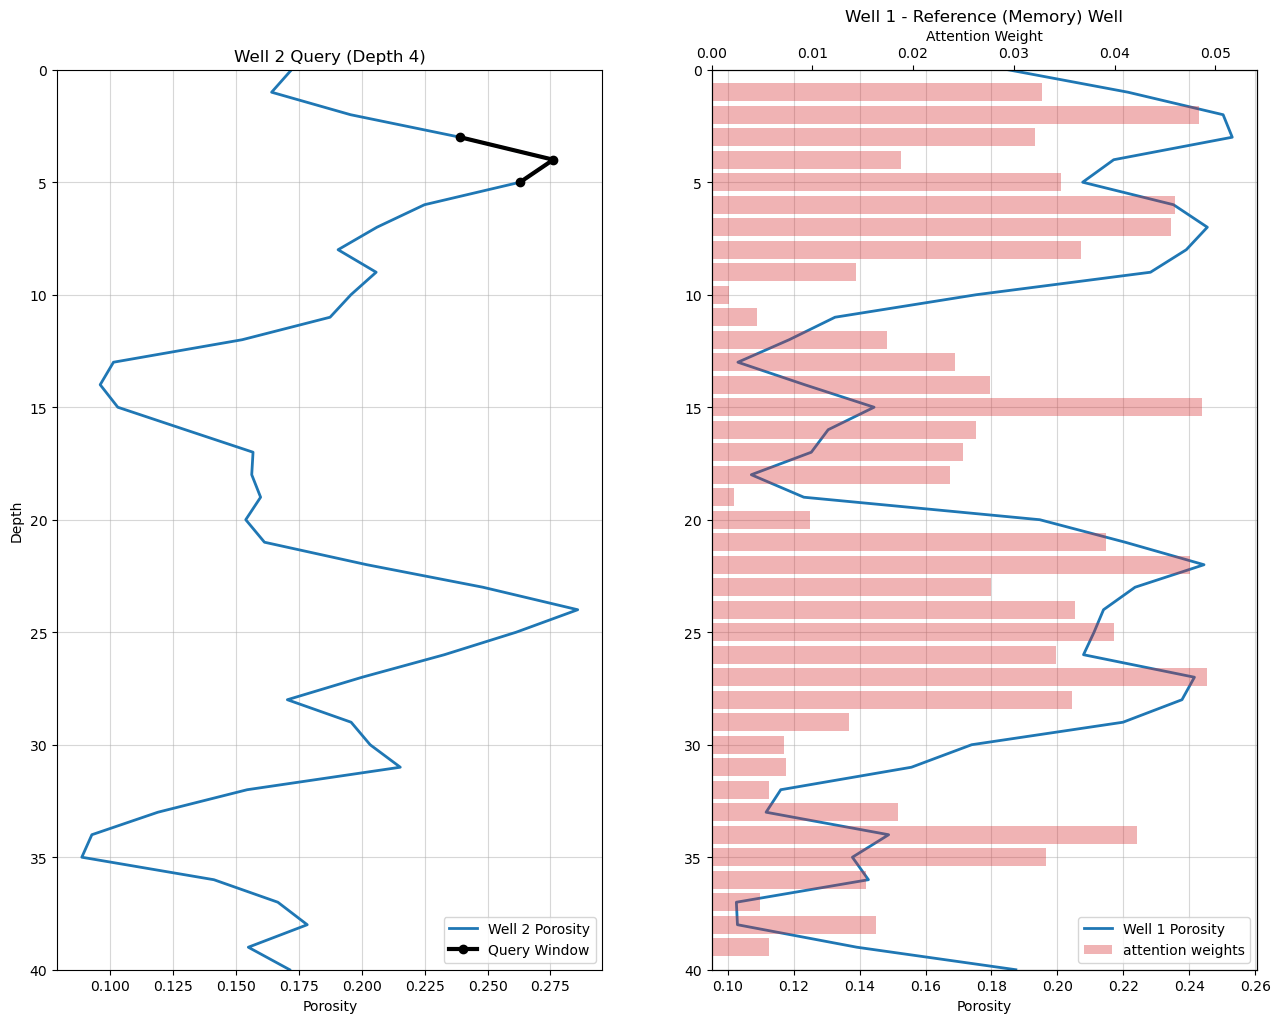

In [7]:
depth_index = 4                                               # set the depth index and the observe the attention weights

plot_attention_provenance(well1,well2,all_weights,Q2,depth_index,window=3) # plot specific query and associated attention weights 

From inspection of the attention weights, it is clear that the model is not simply matching porosity values, but retrieving geological analogs based on local pattern similarity. Higher attention weights are consistently assigned to key windows that exhibit,

* similar porosity magnitudes

* similar local patterns (shape and trend across the window)

In other words, attention responds to pattern alignment over a spatial context rather than pointwise similarity alone. Both the porosity level and the local geological structure contribute to the retrieval behavior.

This illustrates one of the key advantages of attention-based prediction: analog selection is performed using local geological context rather than individual measurements, allowing the model to identify and transfer information from structurally similar patterns in the reference well.

##### Visualize Attention Entropy Along the Prediction Interval

Next, we examine how the concentration of the attention mechanism varies along the full Well 2 prediction interval. We display,

* the Well 2 porosity log (left)

* attention entropy at each prediction location (right), providing a measure of how distributed or concentrated the attention weights are across the reference (memory) well

Attention entropy summarizes the uncertainty associated with analog retrieval. Low entropy indicates that attention is concentrated on a small number of highly similar geological analogs, while higher entropy indicates that attention is distributed across many candidate analogs.

Consequently, low-entropy regions correspond to locations where the model identifies a small set of strong geological matches, whereas high-entropy regions indicate greater ambiguity, with multiple analog patterns contributing to the prediction.

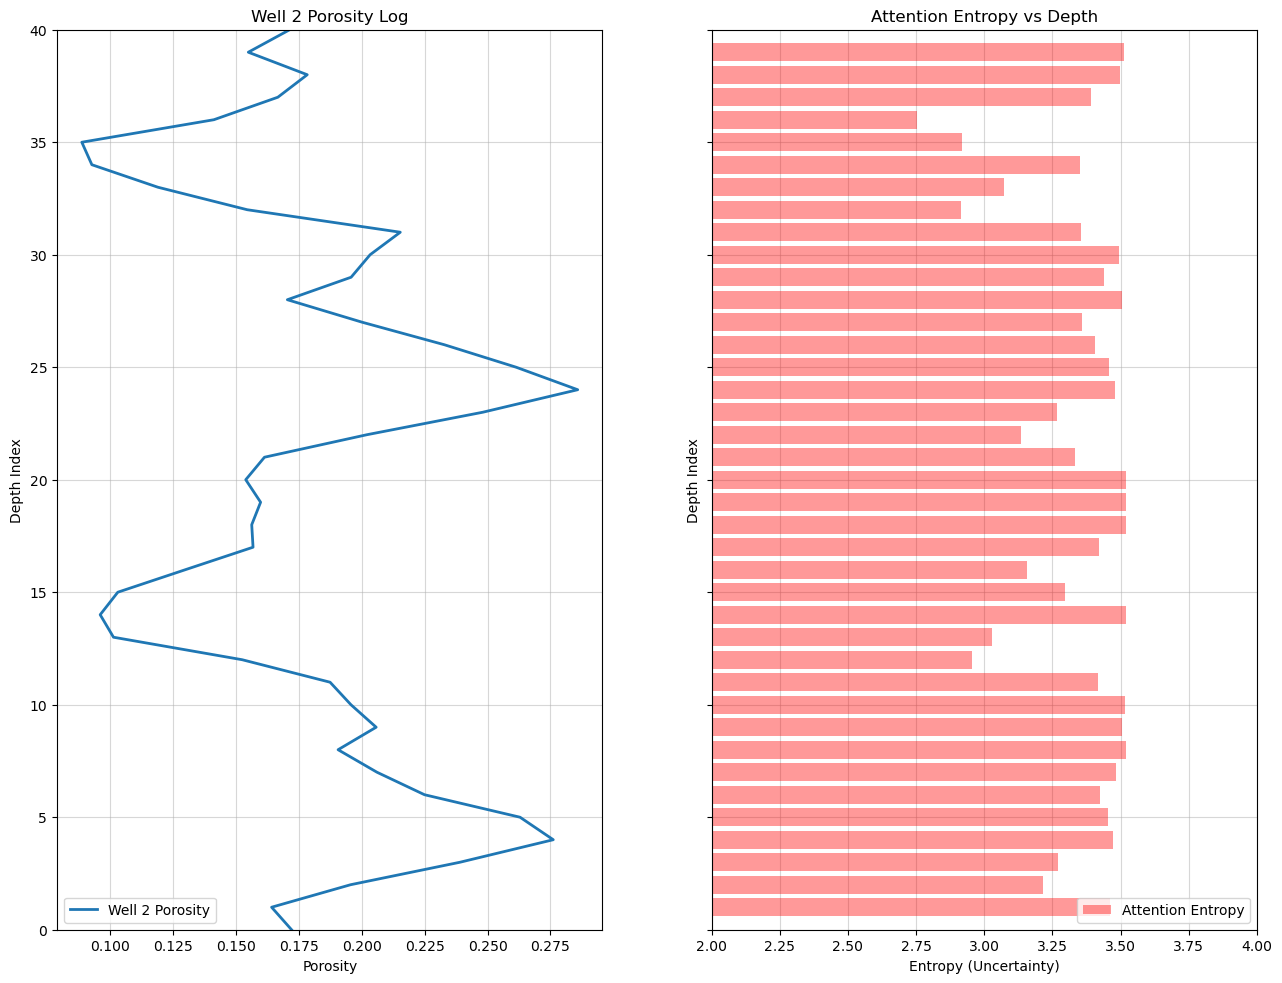

In [8]:
plot_entropy_log(well2,all_weights)                           # plot the attention weight entropy over all predictions

Attention entropy provides insight into how uniquely the model can identify geological analogs within the reference (memory) well.

Locations with low attention entropy are characterized by highly concentrated attention weights, indicating that the model has identified a small number of dominant analogs. In some cases, this occurs because the query exhibits a distinctive local pattern that closely matches only a few locations in the reference well. In other cases, the query may differ substantially from the available analogs, causing the model to concentrate attention on the "least dissimilar" candidates.

* low entropy $\rightarrow$ attention concentrated on a small number of analogs

* high entropy $\rightarrow$ attention distributed across many competing analogs

Higher entropy tends to occur when multiple geological patterns exhibit similar levels of compatibility with the query. In these regions, no single analog clearly dominates, and the prediction is constructed from a broader combination of candidate geological patterns.

Thus, attention entropy should be interpreted as a measure of retrieval concentration rather than prediction quality. Low entropy indicates confident analog selection, while high entropy indicates greater ambiguity in the retrieval process.

##### Visualize the Full Attention Weight Matrix for All Well Log Queries

Now we step back from individual predictions and examine the full attention weight matrix,

* every query in Well 2 is compared against every analog in the reference (memory) well

This matrix provides a complete view of the retrieval process,

* rows correspond to prediction locations (queries)

* columns correspond to reference (memory) analogs (keys)

* each entry represents the attention weight (geological similarity) between a query and a stored analog

In effect, this matrix serves as a complete geological matching map. It reveals how information is retrieved from the reference well and transferred to the target well through similarity-based analog selection.

Patterns within the matrix often highlight recurring geological structures, intervals with strong analog matches, and regions where multiple competing analogs contribute to the prediction. As a result, the organization of attention becomes directly visible.

At this point, attention stops looking like a collection of equations and starts looking like a map of geological relationships. In many ways, the attention matrix becomes a fingerprint of how the model organizes, retrieves, and reuses subsurface patterns.

* and yes, it is beginning to look like something that belongs on a T-shirt!

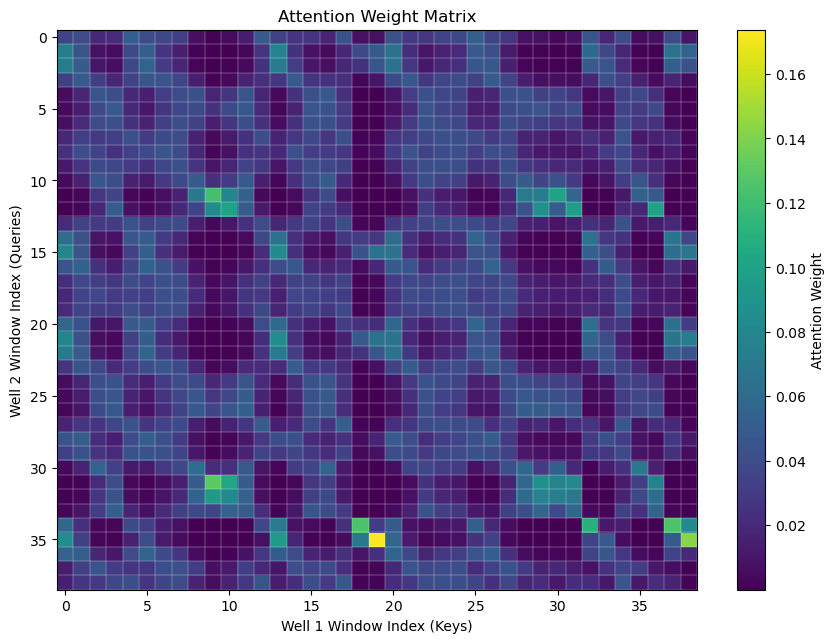

In [9]:
plot_full_attention_matrix(all_weights)                       # plot the full attention matrix over all queries and keys

The attention matrix reveals how geological information is transferred from the reference (memory) well to the target well through similarity-based analog retrieval. 

* bright regions indicate stored analogs that strongly influence the prediction, while diffuse regions indicate that multiple analogs contribute to the retrieved permeability estimate.

#### Comments

In this chapter, we introduced the core ideas behind attention mechanisms through a geoscience-driven analog and missing well log prediction examples. 

* starting from simple analog matching and progressively building toward full matrix-based retrieval, we showed how attention provides a flexible framework for linking a query location to a set of stored geological analogs represented by keys.

Attention is now a foundational component of modern machine learning systems, including transformer architectures and large language models, where it enables the learning of complex, multiscale relationships.

* by using similarity measures such as the dot product, these models are able to capture not just local pointwise similarity, but coherent structure, trends, and dependencies across extended contexts.

In our geological formulation, this translates directly into the ability to,

* recognize similar subsurface patterns across wells

* integrate information from distributed analogs

* adaptively weight their contributions to prediction.

The result is a powerful mechanism that naturally connects local observations with larger-scale geological structure, making attention particularly well suited for spatial and subsurface prediction problems.

```{admonition} Ultimately, attention can be interpreted as,
:class: remove-from-content-only

a learnable pattern retrieval system: one that replaces fixed local assumptions with dynamic, data-driven matching across scales.
```

From this perspective, attention is less about neural networks and more about a familiar scientific task,

* finding the most relevant analogs and learning how strongly they should influence our prediction.

Check out my [shared resource inventory](https://michaelpyrcz.com/my-resources) and the YouTube lecture links at the start of this chapter with resource links in the videos' descriptions.

I hope this is helpful,

*Michael*

#### About the Author

<figure style="text-align: center;">
  <img src="_static/intro/michael_pyrcz_officeshot_jacket.jpg" style="display: block; margin: 0 auto; width: 70%;">
  <figcaption style="text-align: center;"> Professor Michael Pyrcz in his office on the 40 acres, campus of The University of Texas at Austin.
</figcaption>
</figure>

Michael Pyrcz is a professor in the [Cockrell School of Engineering](https://cockrell.utexas.edu/faculty-directory/alphabetical/p), and the [Jackson School of Geosciences](https://www.jsg.utexas.edu/researcher/michael_pyrcz/), at [The University of Texas at Austin](https://www.utexas.edu/), where he researches and teaches subsurface, spatial data analytics, geostatistics, and machine learning. Michael is also,

* the principal investigator of the [Energy Analytics](https://fri.cns.utexas.edu/energy-analytics) freshmen research initiative and a core faculty in the Machine Learn Laboratory in the College of Natural Sciences, The University of Texas at Austin

* an associate editor for [Computers and Geosciences](https://www.sciencedirect.com/journal/computers-and-geosciences/about/editorial-board), and a board member for [Mathematical Geosciences](https://link.springer.com/journal/11004/editorial-board), the International Association for Mathematical Geosciences. 

Michael has written over 90 [peer-reviewed publications](https://scholar.google.com/citations?user=QVZ20eQAAAAJ&hl=en), a [Python package](https://pypi.org/project/geostatspy/) for spatial data analytics, co-authored a textbook on spatial data analytics, [Geostatistical Reservoir Modeling](https://www.amazon.com/Geostatistical-Reservoir-Modeling-Michael-Pyrcz/dp/0199731446) and author of two recently released e-books, [Applied Geostatistics in Python: a Hands-on Guide with GeostatsPy](https://geostatsguy.github.io/GeostatsPyDemos_Book/intro.html) and [Applied Machine Learning in Python: a Hands-on Guide with Code](https://geostatsguy.github.io/MachineLearningDemos_Book/intro.html).

All of Michael’s university lectures are available on his [YouTube Channel](https://www.youtube.com/@GeostatsGuyLectures) with links to 100s of Python interactive dashboards and well-documented workflows in over 40 repositories on his [GitHub account](https://github.com/GeostatsGuy), to support any interested students and working professionals with evergreen content. To find out more about Michael’s work and shared educational resources visit his [Website](www.michaelpyrcz.com).

#### Want to Work Together?

I hope this content is helpful to those that want to learn more about subsurface modeling, data analytics and machine learning. Students and working professionals are welcome to participate.

* Want to invite me to visit your company for training, mentoring, project review, workflow design and / or consulting? I'd be happy to drop by and work with you! 

* Interested in partnering, supporting my graduate student research or my Subsurface Data Analytics and Machine Learning consortium (co-PI is Professor John Foster)? My research combines data analytics, stochastic modeling and machine learning theory with practice to develop novel methods and workflows to add value. We are solving challenging subsurface problems!

* I can be reached at mpyrcz@austin.utexas.edu.

I'm always happy to discuss,

*Michael*

Michael Pyrcz, Ph.D., P.Eng. Professor, Cockrell School of Engineering and The Jackson School of Geosciences, The University of Texas at Austin

More Resources Available at: [Twitter](https://twitter.com/geostatsguy) | [GitHub](https://github.com/GeostatsGuy) | [Website](http://michaelpyrcz.com) | [GoogleScholar](https://scholar.google.com/citations?user=QVZ20eQAAAAJ&hl=en&oi=ao) | [Geostatistics Book](https://www.amazon.com/Geostatistical-Reservoir-Modeling-Michael-Pyrcz/dp/0199731446) | [YouTube](https://www.youtube.com/channel/UCLqEr-xV-ceHdXXXrTId5ig)  | [Applied Geostats in Python e-book](https://geostatsguy.github.io/GeostatsPyDemos_Book/intro.html) | [Applied Machine Learning in Python e-book](https://geostatsguy.github.io/MachineLearningDemos_Book/) | [LinkedIn](https://www.linkedin.com/in/michael-pyrcz-61a648a1)